In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snb
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers,utils
 

# Load Dataset

In [43]:
image_width = 64
image_height = 64
image_batch = 32

train_ds = utils.image_dataset_from_directory(
    "./dataset/train",
    image_size=(image_width, image_height),
    batch_size=image_batch
)

val_ds = utils.image_dataset_from_directory(
    "./dataset/train",
    image_size=(image_width, image_height),
    batch_size=image_batch
)

test_ds = utils.image_dataset_from_directory(
    "./dataset/test",
    image_size=(image_width, image_height),
    batch_size=image_batch
)

Found 4662 files belonging to 3 classes.
Found 4662 files belonging to 3 classes.
Found 215 files belonging to 3 classes.


In [44]:
X_train = np.concatenate([x for x, y in train_ds])
y_train = np.concatenate([y for x, y in train_ds])

X_val = np.concatenate([x for x, y in val_ds])
y_val = np.concatenate([y for x, y in val_ds])

X_test = np.concatenate([x for x, y in test_ds])
y_test = np.concatenate([y for x, y in test_ds])

(64, 64, 3)


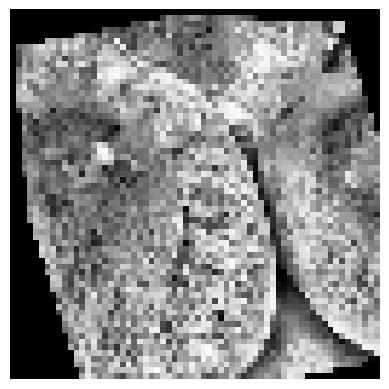

(64, 64, 3)


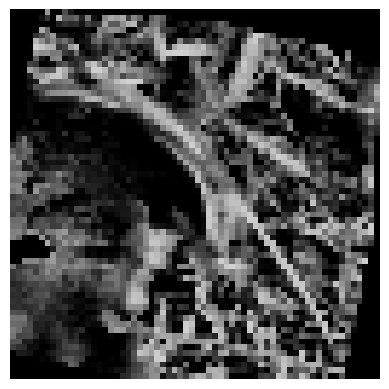

(64, 64, 3)


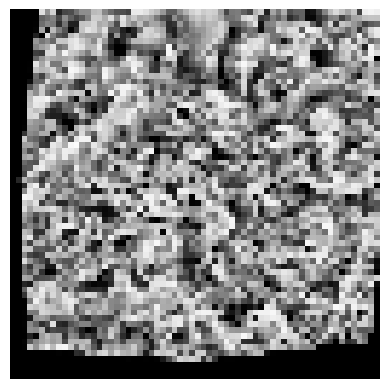

(64, 64, 3)


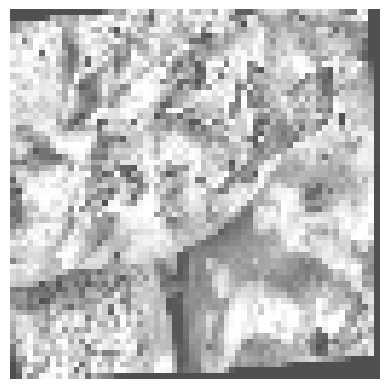

(64, 64, 3)


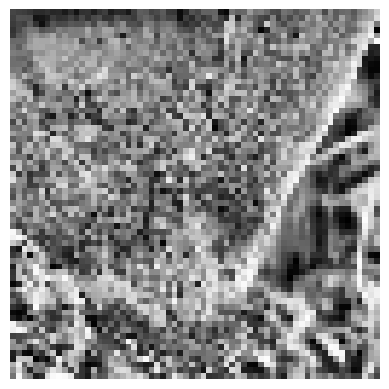

(64, 64, 3)


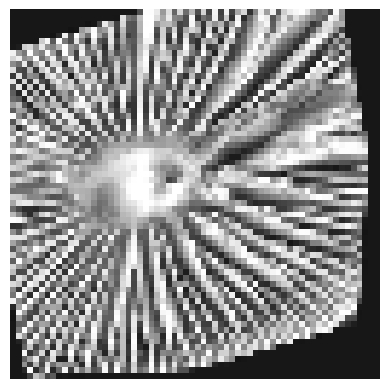

(64, 64, 3)


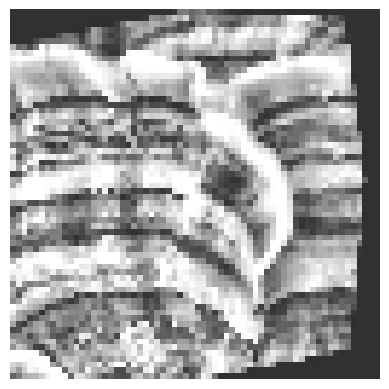

(64, 64, 3)


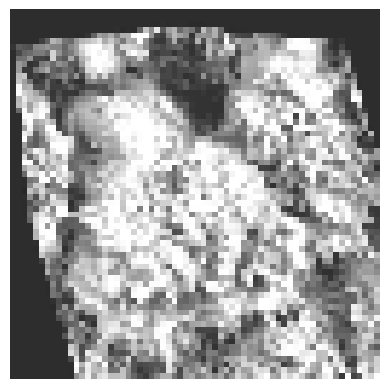

(64, 64, 3)


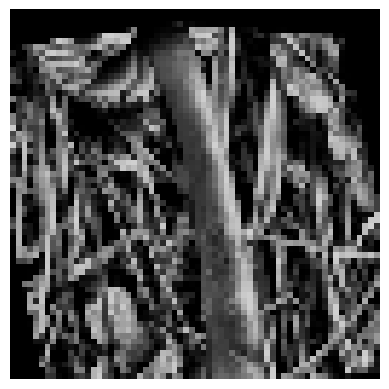

(64, 64, 3)


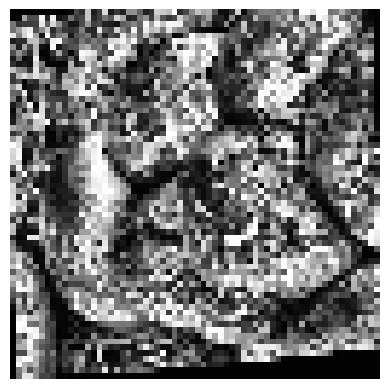

In [45]:
for x in X_train[9:19]:
    print(x.shape)
    img_fixed = x.astype(np.uint8)
    plt.imshow(img_fixed)
    plt.axis('off') 
    plt.show()

In [46]:
def build_cnn(num_classes: int, config: dict) -> keras.Model:
    inputs = keras.Input(shape=(image_width, image_width, 3))
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.RandomFlip("horizontal")(x)

    for filters in config["filters"]:
        x = layers.Conv2D(filters, kernel_size=config["kernel_size"], padding="same", use_bias=not config["batch_norm"])(x)
        if config["batch_norm"]:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(config["dropout"])(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name=config["name"])

In [ ]:
build_cnn({
    
})